<a href="https://colab.research.google.com/github/FuturisticLover123/learning/blob/main/DataAnalys/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from sklearn.datasets import fetch_california_housing
import pandas as pd

# загрузка набора данных
housing = fetch_california_housing()
X, y = housing.data, housing.target
X = pd.DataFrame(X, columns=housing.feature_names)
# подготовка признаков
X = X.drop(['Population', 'AveBedrms', 'AveOccup'], axis=1)

In [4]:
!pip install xgboost

In [5]:
# разделение данных на обучающий и тестовый наборы
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# обучение модели XGBoost
from xgboost import XGBRegressor
model = XGBRegressor(objective='reg:squarederror', random_state=4)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=4, ...)

In [6]:
y_pred = model.predict(X_test)

In [7]:
from sklearn.metrics import r2_score

In [8]:
r2_score(y_pred, y_test)

0.7929665197314876

In [9]:
import shap
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

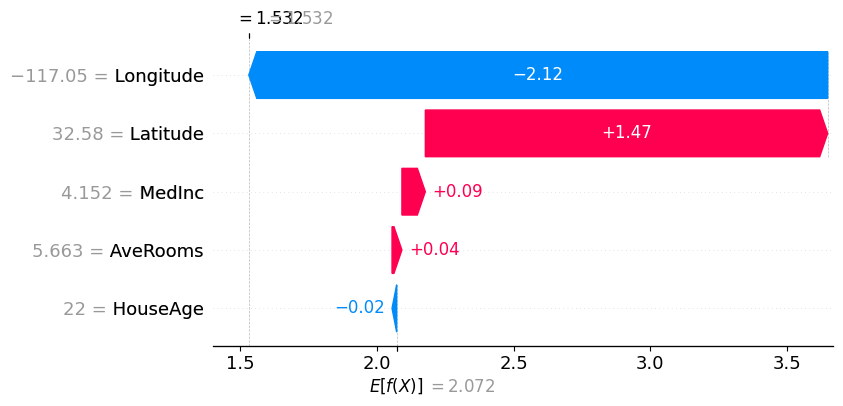

In [10]:
# визуализация SHAP-значений для первого образца
shap.plots.waterfall(shap_values[0])

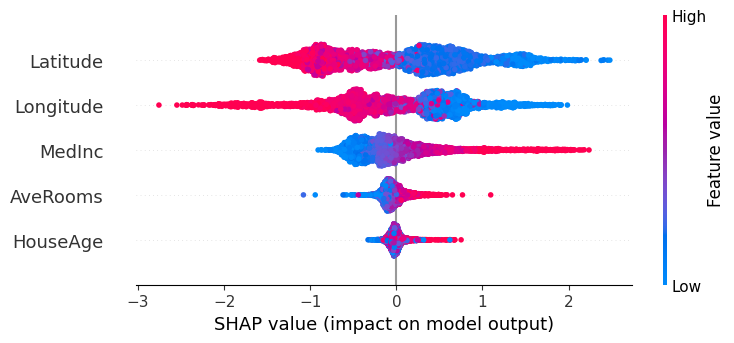

In [11]:
shap.plots.beeswarm(shap_values)

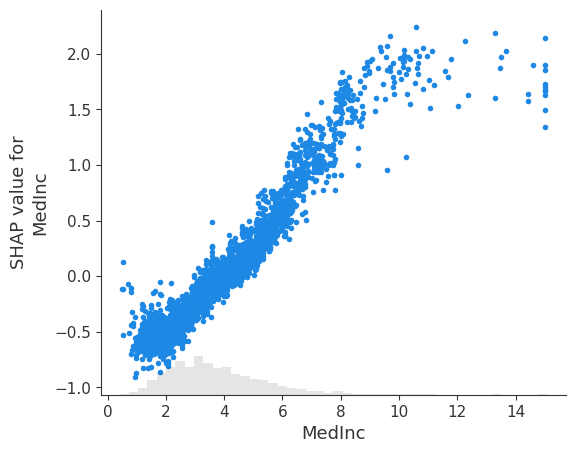

In [12]:
shap.plots.scatter(shap_values[:,"MedInc"])

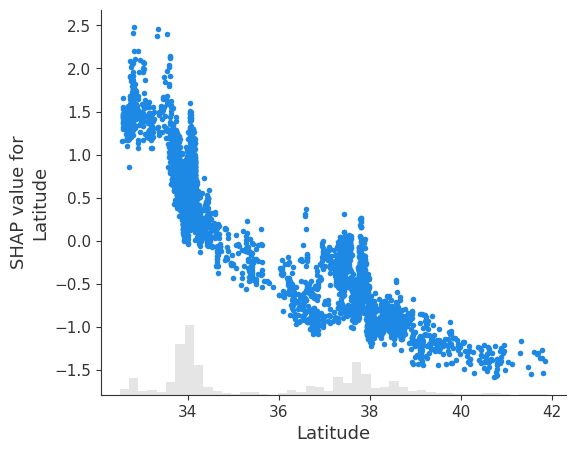

In [13]:
shap.plots.scatter(shap_values[:,"Latitude"])